# 02 — CSP + LDA on 64-channel epochs

Common Spatial Patterns + Linear Discriminant Analysis. CSP learns spatial
filters that maximise variance ratio between T1 and T2; LDA classifies on
log-variance features. See `PIPELINE_PLAN.md` §6.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.run_02_csp_lda import main as run_csp_lda


## Train + evaluate

In [2]:
run_csp_lda()


=== Window w0.0-4.0 ===
  epochs: train=1849 val=340 test=296
Computing rank from data with rank=None
    Using tolerance 0.00044 (2.2e-16 eps * 64 dim * 3.1e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00044 (2.2e-16 eps * 64 dim * 3.1e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00044 (2.2e-16 eps * 64 dim * 3.1e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
R

## Inspect saved results

In [3]:
import json
result = json.loads((ROOT / 'reports' / 'csp_lda_results.json').read_text())
print('Winning window:', result['winning_window'])
print('Winning n_components:', result['winning_n_components'])
print('Test metrics:')
for k, v in result['test_metrics'].items():
    print(f'  {k}: {v}')


Winning window: [0.0, 4.0]
Winning n_components: 4
Test metrics:
  accuracy: 0.5709459459459459
  macro_f1: 0.5705489232878277
  per_class_f1: [0.5574912891986062, 0.5836065573770491]
  confusion_matrix: [[80, 66], [61, 89]]


## CSP scalp patterns

The killer interpretability plot: each topomap is one CSP spatial pattern.
For successful left/right motor imagery decoding, expect contralateral
red/blue blobs near C3 / C4 in the top patterns.


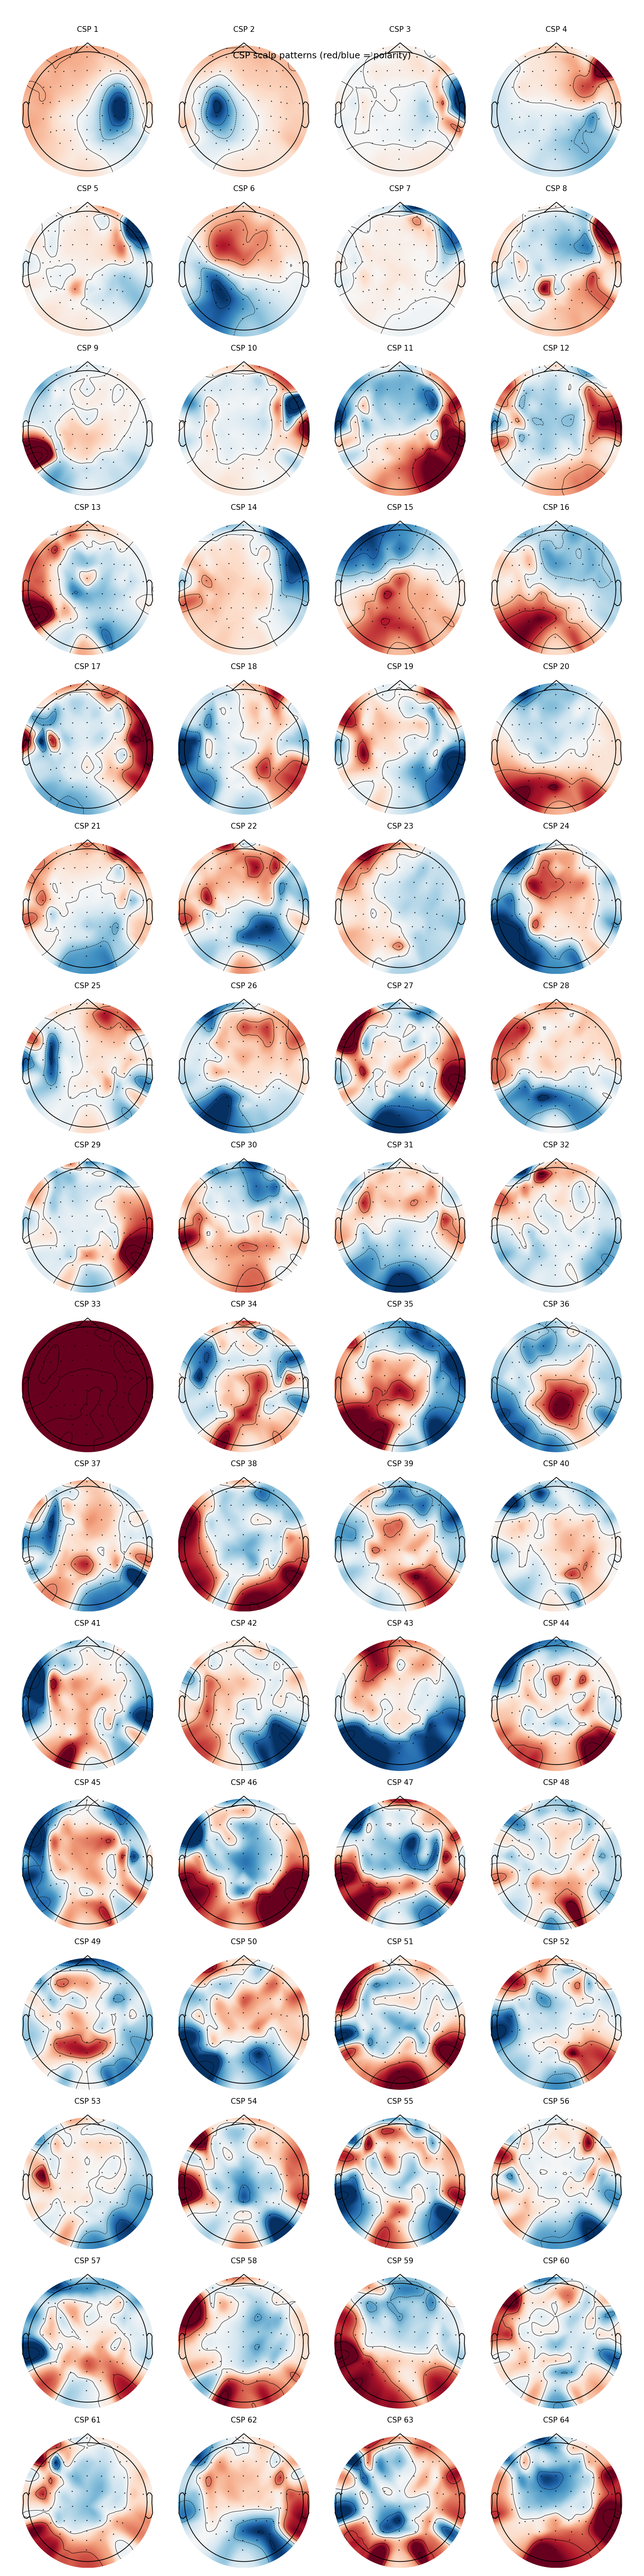

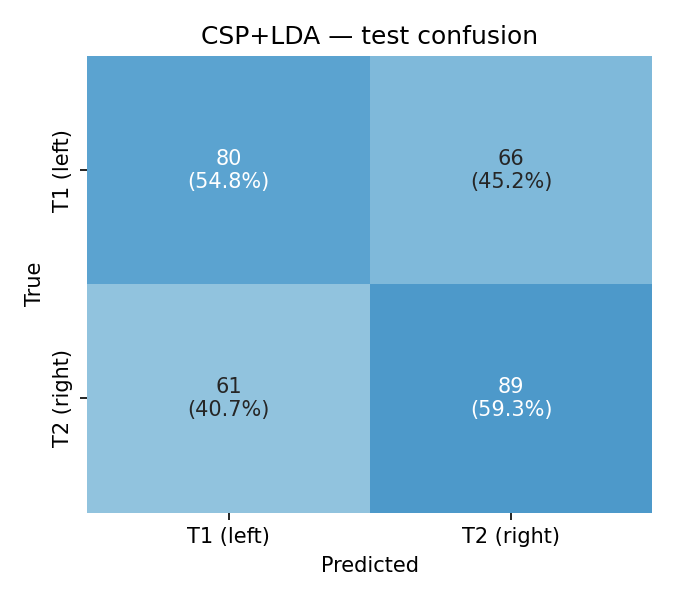

In [4]:
from IPython.display import Image, display
display(Image(str(ROOT / 'reports' / 'figures' / 'csp_topomaps.png')))
display(Image(str(ROOT / 'reports' / 'figures' / 'csp_lda_confusion.png')))
